In [1]:
import sys
sys.path.append('/machfs/swhite/pyml/pyacal-test')
import pyacal
import os
import warnings
import at
import matplotlib.pyplot as plt
import time
import numpy
plt.rcParams['figure.figsize'] = [20, 10]

In [2]:
pyacal.set_facility('esrf')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    path = '/operation/beamdyn/matlab/optics/sr/theory/'
    ring = at.load_lattice('./betamodel.mat', use='betamodel')
pyacal.set_model('EBS', ring)
devices = pyacal._get_devices()
facility = pyacal._get_facility()

In [3]:
bpms = devices.FamBPMs()
correctors = devices.FamCMs()

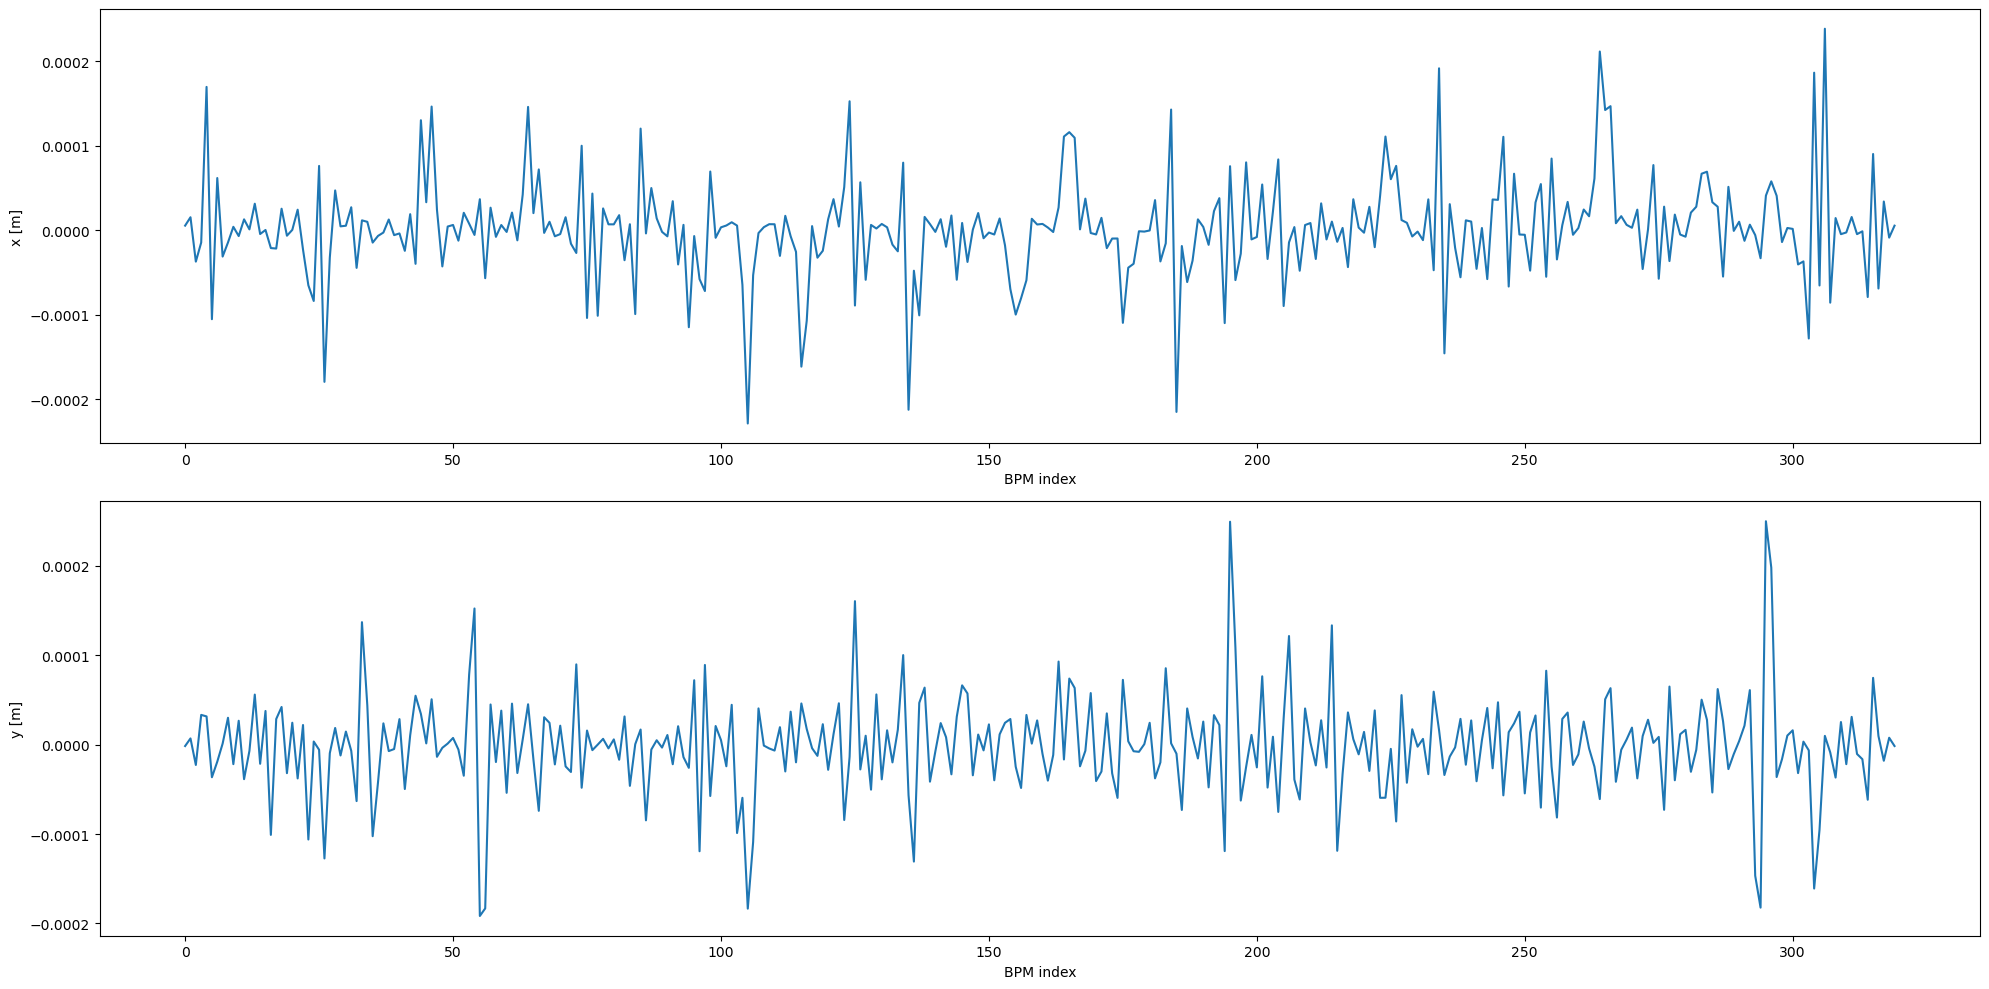

In [5]:
plt.subplot(211)
plt.plot(bpms.orbx)
plt.xlabel('BPM index')
plt.ylabel('x [m]')
plt.subplot(212)
plt.plot(bpms.orby)
plt.xlabel('BPM index')
plt.ylabel('y [m]')
plt.tight_layout()
plt.show()

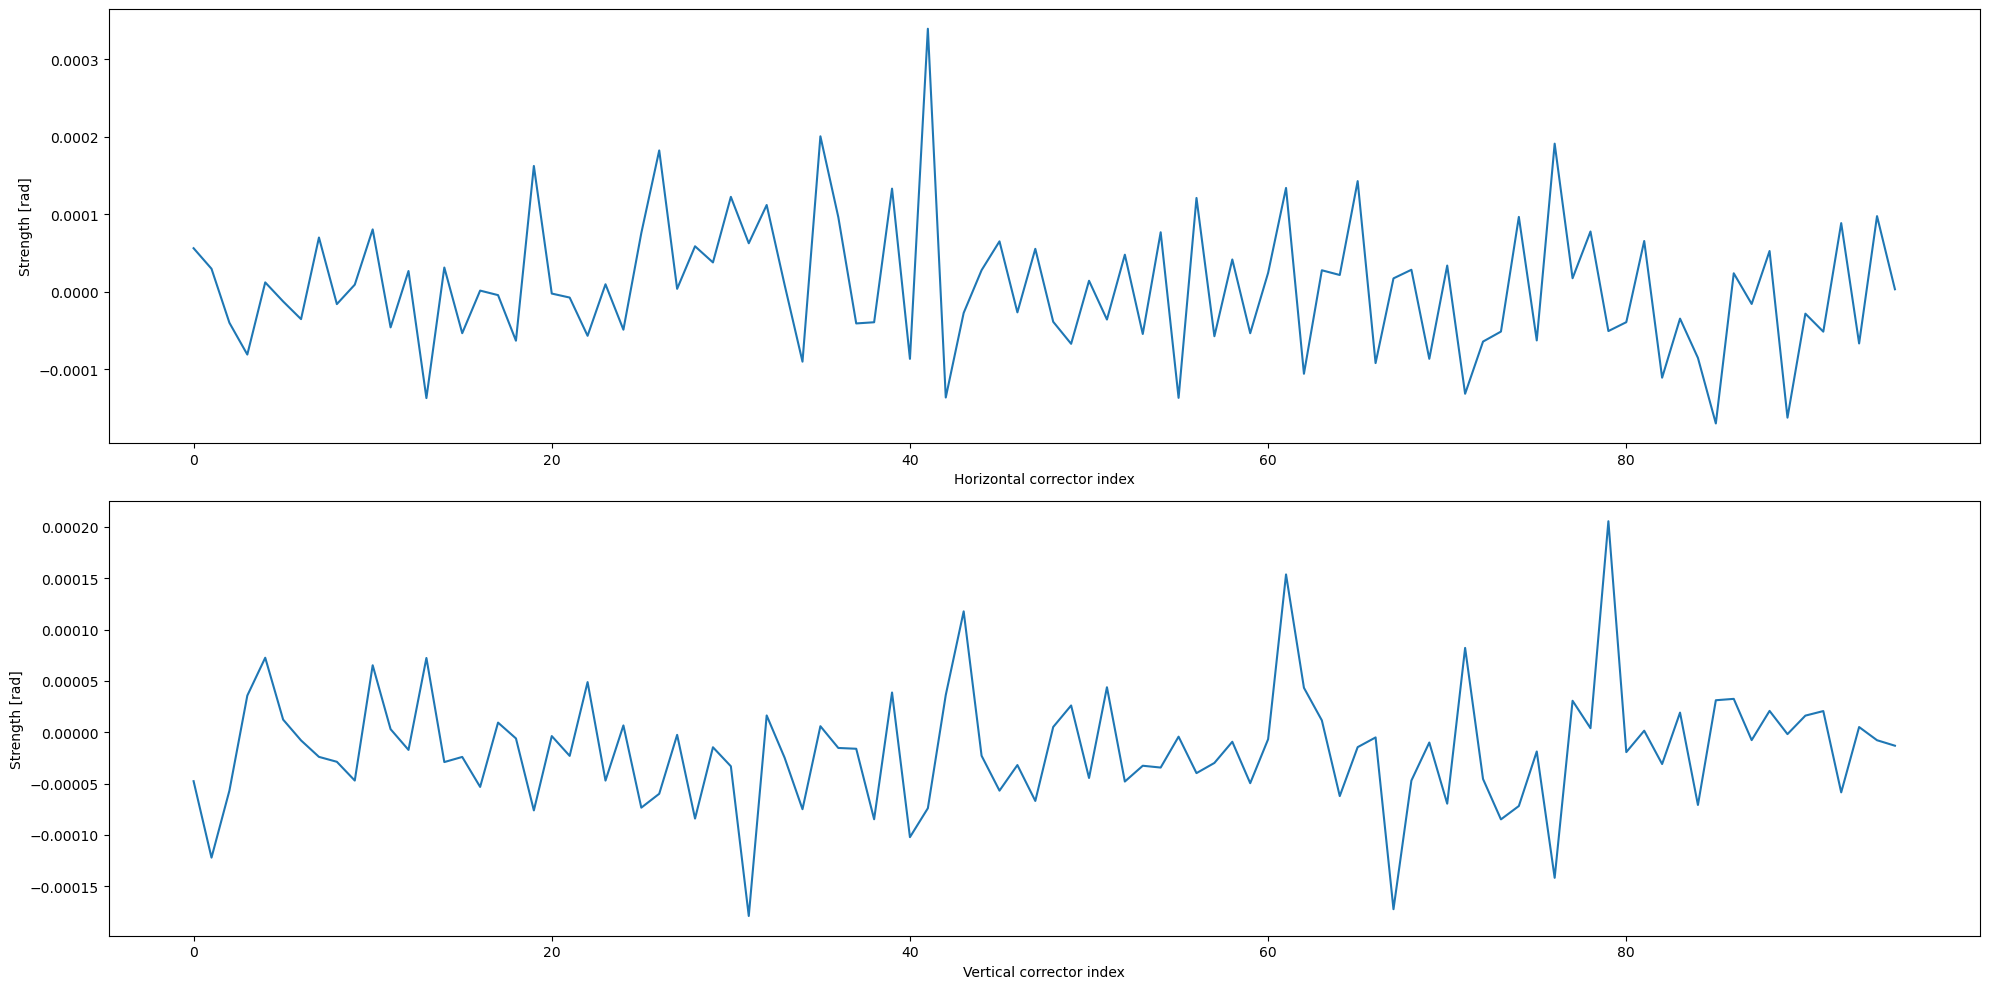

In [6]:
plt.subplot(211)
plt.plot(correctors.strengths_hcm)
plt.xlabel('Horizontal corrector index')
plt.ylabel('Strength [rad]')
plt.subplot(212)
plt.plot(correctors.strengths_vcm)
plt.xlabel('Vertical corrector index')
plt.ylabel('Strength [rad]')
plt.tight_layout()
plt.show()

In [7]:
ch_sh1_c04A = correctors.devices[0]
print(ch_sh1_c04A.devname)
str0 = ch_sh1_c04A.strength
print(str0)

CH-SH1-C04-A
5.5936979148218764e-05


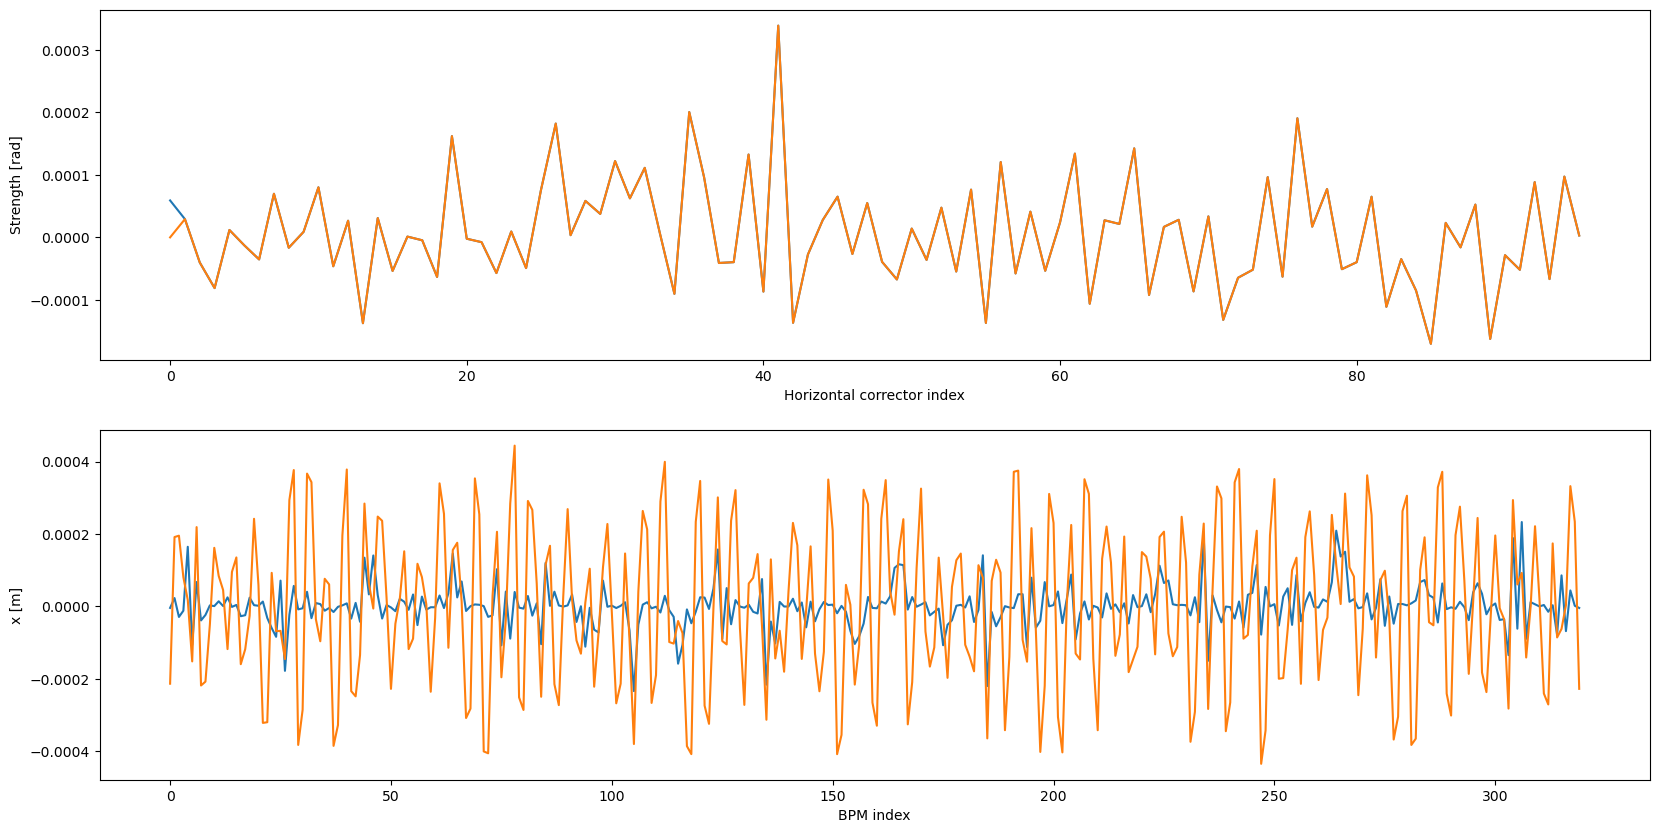

In [11]:
hstr0 = correctors.strengths_hcm
horb0 = bpms.orbx

ch_sh1_c04A.set_strength(0.0)
time.sleep(2)
horb1 = bpms.orbx
hstr1 = correctors.strengths_hcm

ch_sh1_c04A.set_strength(str0)

plt.subplot(211)
plt.plot(hstr0, label='Initial')
plt.plot(hstr1, label='Final')
plt.xlabel('Horizontal corrector index')
plt.ylabel('Strength [rad]')

plt.subplot(212)
plt.plot(horb0, label='Initial')
plt.plot(horb1, label='Final')
plt.xlabel('BPM index')
plt.ylabel('x [m]')
plt.show()